# Layer 0 -- Kernel Primitives

Pure-function primitives: exact kernels, approximate kernels, centering, HSIC, and MMD.

This notebook demonstrates the Layer 0 primitives -- the pure functions that underpin all fairness metrics and kernel computations in fairkl. These functions are stateless, use only `keras.ops`, and can be called independently without any model infrastructure.

In [1]:
from __future__ import annotations

import os

os.environ["KERAS_BACKEND"] = "jax"

import matplotlib.pyplot as plt
import numpy as np

import fairkl
from _style import SCATTER_KW, style_ax

## Exact Kernel Matrices

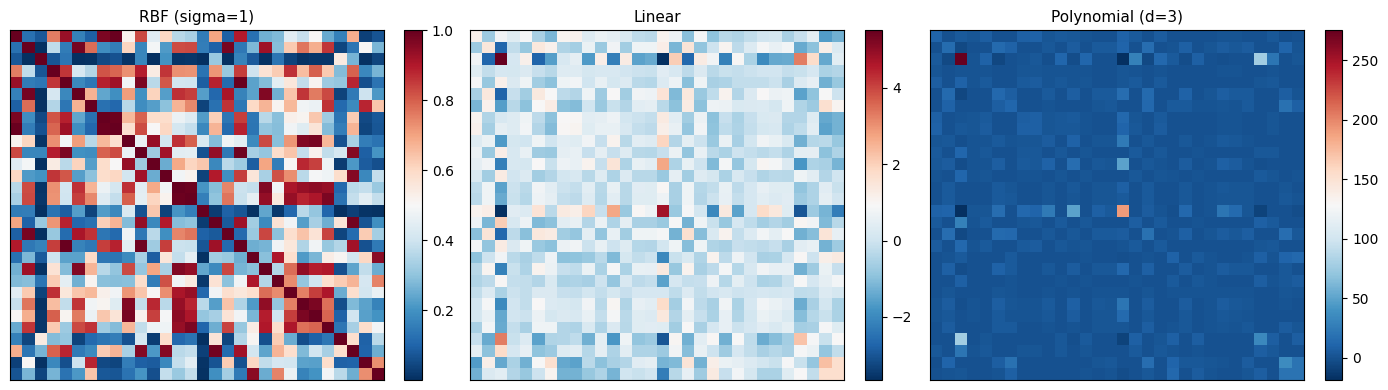

In [2]:
rng = np.random.default_rng(42)
X = rng.standard_normal((30, 2)).astype("float32")

K_rbf = np.array(fairkl.rbf_kernel(X, sigma=1.0))
K_lin = np.array(fairkl.linear_kernel(X))
K_poly = np.array(fairkl.polynomial_kernel(X, degree=3, coef0=1.0))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, K, title in zip(
    axes, [K_rbf, K_lin, K_poly], ["RBF (sigma=1)", "Linear", "Polynomial (d=3)"]
):
    im = ax.imshow(K, cmap="RdBu_r", aspect="auto")
    ax.set_title(title, fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

## RBF Bandwidth Effect

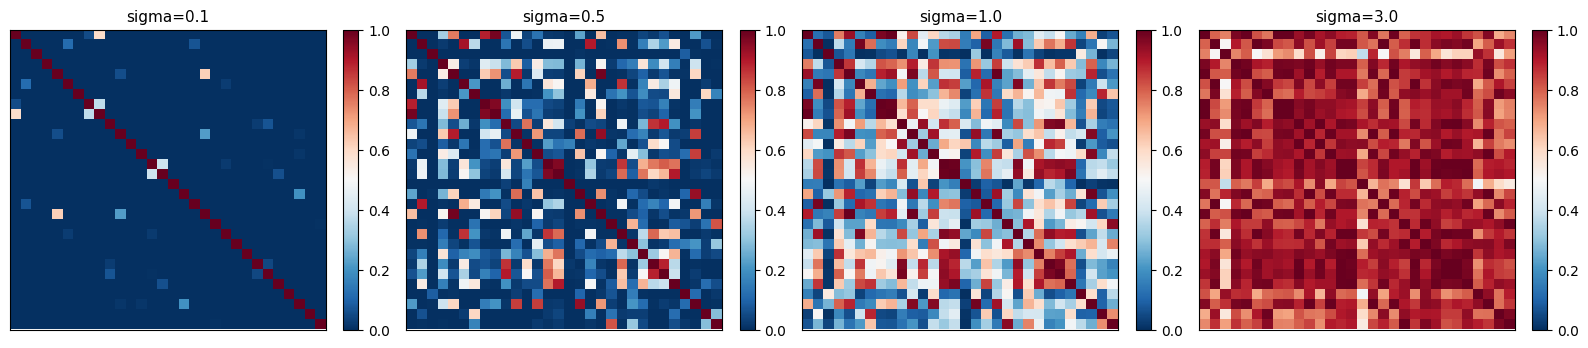

In [3]:
sigmas = [0.1, 0.5, 1.0, 3.0]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, s in zip(axes, sigmas):
    K = np.array(fairkl.rbf_kernel(X, sigma=s))
    im = ax.imshow(K, cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")
    ax.set_title(f"sigma={s}", fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

## Kernel Centering

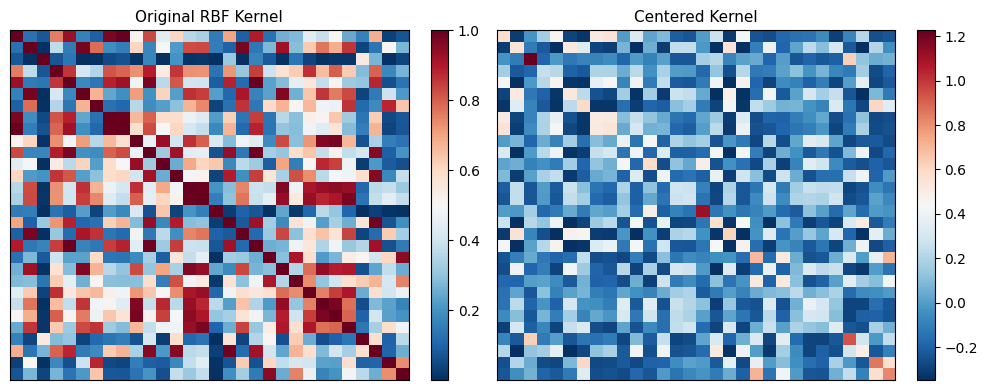

In [4]:
K_centered = np.array(fairkl.center_kernel(K_rbf))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].imshow(K_rbf, cmap="RdBu_r", aspect="auto")
axes[0].set_title("Original RBF Kernel", fontsize=11)
plt.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(K_centered, cmap="RdBu_r", aspect="auto")
axes[1].set_title("Centered Kernel", fontsize=11)
plt.colorbar(im1, ax=axes[1], fraction=0.046)
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

## HSIC: Measuring Statistical Dependence

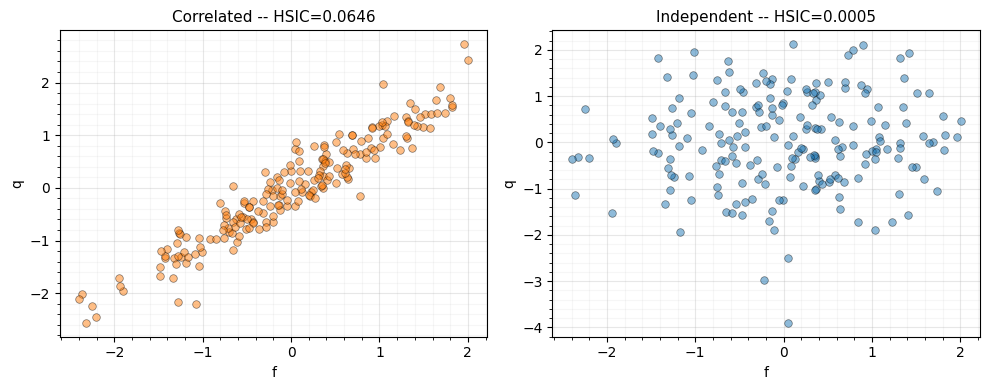

In [5]:
n = 200
rng = np.random.default_rng(0)
f = rng.standard_normal((n, 1)).astype("float32")
q_corr = (f + 0.3 * rng.standard_normal((n, 1))).astype("float32")
q_indep = rng.standard_normal((n, 1)).astype("float32")

hsic_corr = float(fairkl.hsic_rbf(f, q_corr))
hsic_indep = float(fairkl.hsic_rbf(f, q_indep))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(f, q_corr, c="C1", **SCATTER_KW)
axes[0].set_title(f"Correlated -- HSIC={hsic_corr:.4f}", fontsize=11)
axes[0].set_xlabel("f")
axes[0].set_ylabel("q")
style_ax(axes[0])
axes[1].scatter(f, q_indep, c="C0", **SCATTER_KW)
axes[1].set_title(f"Independent -- HSIC={hsic_indep:.4f}", fontsize=11)
axes[1].set_xlabel("f")
axes[1].set_ylabel("q")
style_ax(axes[1])
plt.tight_layout()
plt.show()

## CKA: Normalized Dependence (Biased + Debiased)

CKA normalizes HSIC to [0, 1]: `CKA = HSIC(K,L) / sqrt(HSIC(K,K) * HSIC(L,L))`. **Debiased CKA** (Murphy et al., ICLR 2024) corrects the finite-sample bias that inflates biased CKA in high-dimensional settings.

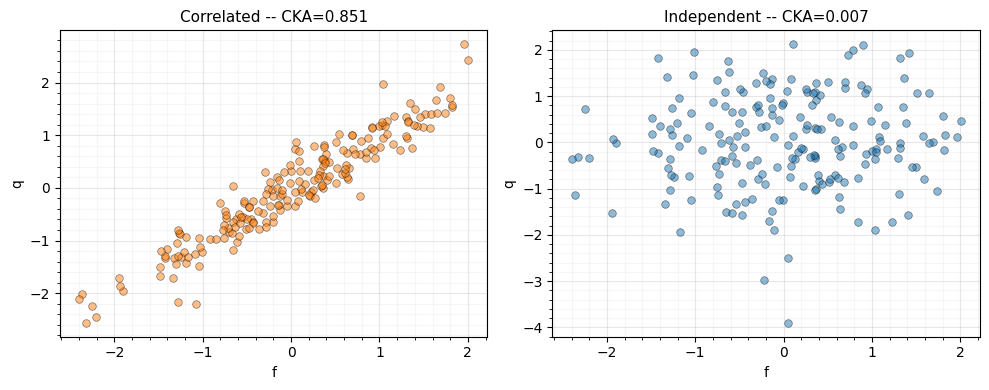

In [6]:
# Scatter comparison — same pairs as HSIC, now with CKA values.
cka_corr_val = float(fairkl.cka_rbf(f, q_corr))
cka_indep_val = float(fairkl.cka_rbf(f, q_indep))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(f, q_corr, c="C1", **SCATTER_KW)
axes[0].set_title(f"Correlated -- CKA={cka_corr_val:.3f}", fontsize=11)
axes[0].set_xlabel("f")
axes[0].set_ylabel("q")
style_ax(axes[0])
axes[1].scatter(f, q_indep, c="C0", **SCATTER_KW)
axes[1].set_title(f"Independent -- CKA={cka_indep_val:.3f}", fontsize=11)
axes[1].set_xlabel("f")
axes[1].set_ylabel("q")
style_ax(axes[1])
plt.tight_layout()
plt.show()

### Biased vs Debiased CKA

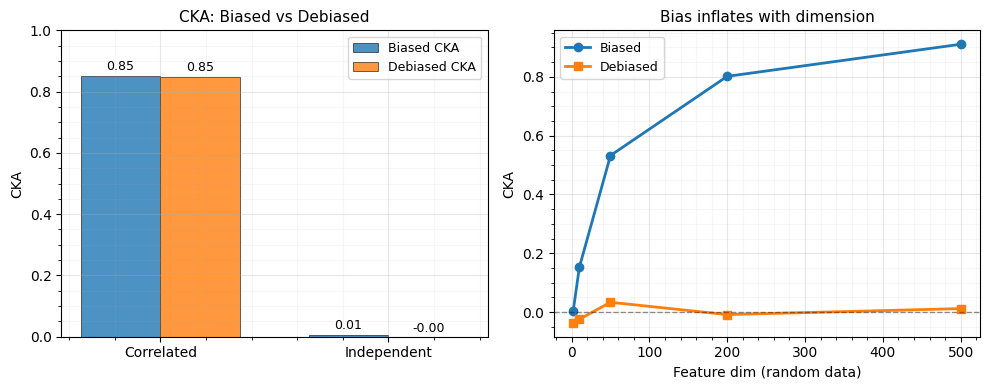

In [7]:
cka_corr = float(fairkl.cka_rbf(f, q_corr))
cka_indep = float(fairkl.cka_rbf(f, q_indep))
cka_corr_db = float(fairkl.cka_rbf(f, q_corr, debiased=True))
cka_indep_db = float(fairkl.cka_rbf(f, q_indep, debiased=True))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels = ["Correlated", "Independent"]
biased = [cka_corr, cka_indep]
debiased = [cka_corr_db, cka_indep_db]
x_pos = np.arange(len(labels))
w = 0.35

bars1 = axes[0].bar(
    x_pos - w / 2,
    biased,
    w,
    color="C0",
    edgecolor="k",
    linewidth=0.5,
    alpha=0.8,
    label="Biased CKA",
)
bars2 = axes[0].bar(
    x_pos + w / 2,
    debiased,
    w,
    color="C1",
    edgecolor="k",
    linewidth=0.5,
    alpha=0.8,
    label="Debiased CKA",
)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("CKA")
axes[0].set_ylim(0, 1)
axes[0].set_title("CKA: Biased vs Debiased", fontsize=11)
axes[0].legend(fontsize=9)
for bar in [*bars1, *bars2]:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{bar.get_height():.2f}",
        ha="center",
        fontsize=9,
    )
style_ax(axes[0])

# Show that debiased CKA stays near 0 for high-dim random data
dims = [2, 10, 50, 200, 500]
biased_rand, debiased_rand = [], []
for d in dims:
    Xr = rng.standard_normal((50, d)).astype("float32")
    Yr = rng.standard_normal((50, d)).astype("float32")
    biased_rand.append(float(fairkl.cka_linear(Xr, Yr, debiased=False)))
    debiased_rand.append(float(fairkl.cka_linear(Xr, Yr, debiased=True)))

axes[1].plot(dims, biased_rand, "o-", color="C0", lw=2, markersize=6, label="Biased")
axes[1].plot(
    dims, debiased_rand, "s-", color="C1", lw=2, markersize=6, label="Debiased"
)
axes[1].axhline(0, color="k", ls="--", lw=1, alpha=0.4)
axes[1].set_xlabel("Feature dim (random data)")
axes[1].set_ylabel("CKA")
axes[1].set_title("Bias inflates with dimension", fontsize=11)
axes[1].legend(fontsize=9)
style_ax(axes[1])

plt.tight_layout()
plt.show()

## MMD: Distribution Distance

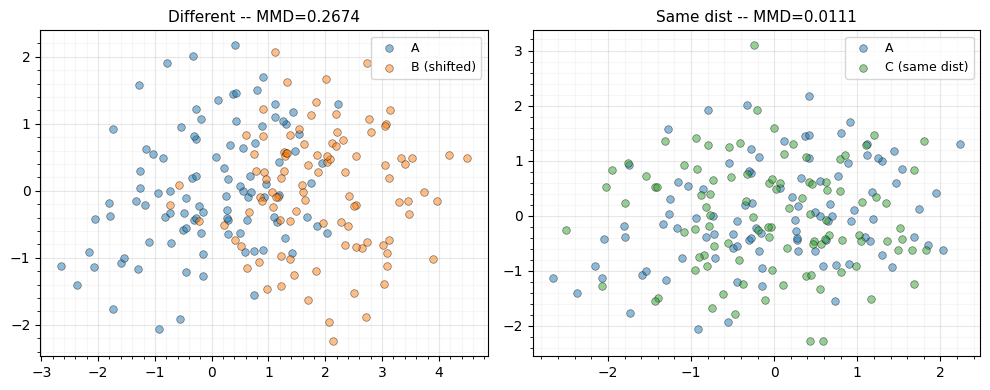

In [8]:
X_a = rng.standard_normal((100, 2)).astype("float32")
X_b = (rng.standard_normal((100, 2)) + np.array([2.0, 0.0])).astype("float32")
X_c = rng.standard_normal((100, 2)).astype("float32")

mmd_diff = float(fairkl.mmd_rbf(X_a, X_b, sigma=1.0))
mmd_same = float(fairkl.mmd_rbf(X_a, X_c, sigma=1.0))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X_a[:, 0], X_a[:, 1], c="C0", label="A", **SCATTER_KW)
axes[0].scatter(X_b[:, 0], X_b[:, 1], c="C1", label="B (shifted)", **SCATTER_KW)
axes[0].set_title(f"Different -- MMD={mmd_diff:.4f}", fontsize=11)
axes[0].legend(fontsize=9)
style_ax(axes[0])
axes[1].scatter(X_a[:, 0], X_a[:, 1], c="C0", label="A", **SCATTER_KW)
axes[1].scatter(X_c[:, 0], X_c[:, 1], c="C2", label="C (same dist)", **SCATTER_KW)
axes[1].set_title(f"Same dist -- MMD={mmd_same:.4f}", fontsize=11)
axes[1].legend(fontsize=9)
style_ax(axes[1])
plt.tight_layout()
plt.show()

## Random Fourier Features Approximation

> **When to use RFF vs exact kernels.** Exact kernel matrices are
> O(n^2) in memory and O(n^2 d) to compute. For n > ~1000 this
> becomes the bottleneck; Random Fourier Features approximate the RBF
> kernel in O(nD) time with D random features, where D << n typically
> suffices. The plots below show how approximation error drops as D
> increases.

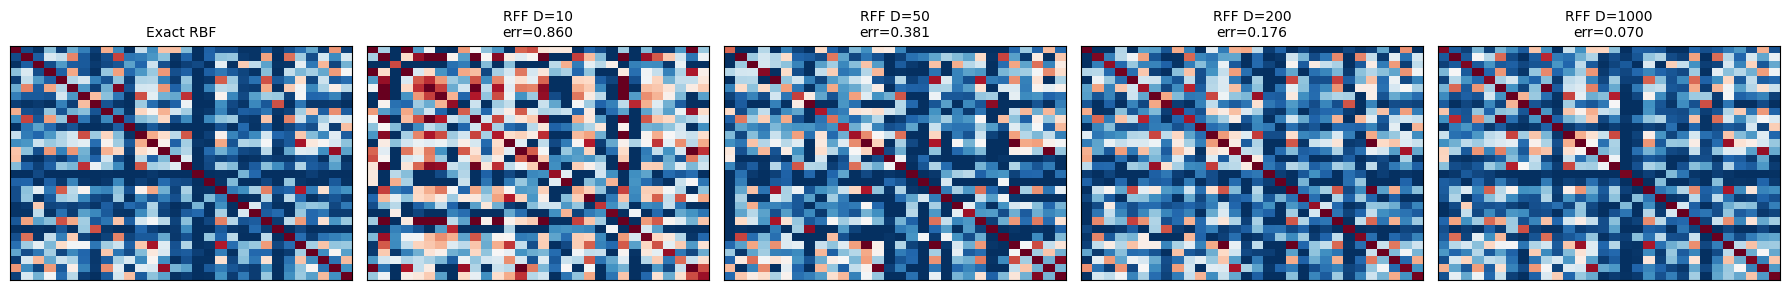

In [9]:
X_small = rng.standard_normal((30, 3)).astype("float32")
K_exact = np.array(fairkl.rbf_kernel(X_small, sigma=1.0))

feature_dims = [10, 50, 200, 1000]
fig, axes = plt.subplots(1, len(feature_dims) + 1, figsize=(18, 3))
axes[0].imshow(K_exact, cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")
axes[0].set_title("Exact RBF", fontsize=10)
axes[0].set_xticks([])
axes[0].set_yticks([])
for ax, D in zip(axes[1:], feature_dims):
    Z = np.array(
        fairkl.random_fourier_features(X_small, n_features=D, sigma=1.0, seed=0)
    )
    K_approx = Z @ Z.T
    ax.imshow(K_approx, cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")
    err = np.linalg.norm(K_exact - K_approx) / np.linalg.norm(K_exact)
    ax.set_title(f"RFF D={D}\nerr={err:.3f}", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()